This notebook serves to do FDR correction on the FST values calculated in PopGen.jl, then creat the plots that appear in the publication.
## FDR Correction of P-values
### Outlier Data

In [ ]:
fdr_upper_tri <- function(df) {
    mat <- as.matrix(df)

    # get indices of upper triangle, excluding diagonal
    upper_idx <- upper.tri(mat, diag = FALSE)

    # extract, adjust, and reassign
    mat[upper_idx] <- p.adjust(mat[upper_idx], method = "fdr")

    # convert back to data.frame if needed
    return(as.data.frame(mat))
}

In [ ]:
outliers <- read.csv("amovafst.outlier.csv",row.names = c("ATL", "GOA", "IVC", "SEN", "VZ"))
outliers

,ATL,GOA,IVC,SEN,VZ
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATL,0.00000000,1.333333e-05,8.000000e-04,5.333333e-05,1.352000e-02
GOA,0.09077964,0.000000e+00,1.333333e-05,1.333333e-05,1.066667e-04
IVC,0.06556440,2.244133e-01,0.000000e+00,8.754667e-02,1.333333e-05
SEN,0.11433826,3.094950e-01,1.488507e-02,0.000000e+00,1.333333e-05
VZ,0.03025292,5.319619e-02,1.647208e-01,2.272569e-01,0.000000e+00


In [ ]:
out.adjust <- fdr_upper_tri(outliers)

### Neutral Data

In [ ]:
neutral <- read.csv("amovafst.neutral.csv", row.names = c("ATL", "GOA", "IVC", "SEN", "VZ"))
neutral

,ATL,GOA,IVC,SEN,VZ
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATL,0.000000000,0.0621333333,1.333333e-05,1.244133e-01,1.340533e-01
GOA,0.001734778,0.0000000000,2.666667e-05,4.205333e-02,5.207467e-01
IVC,0.011386353,0.0055069541,0.000000e+00,1.333333e-05,1.333333e-05
SEN,0.001385251,0.0015187941,5.577405e-03,0.000000e+00,7.477333e-02
VZ,0.001194524,-0.0001867361,6.463505e-03,1.383377e-03,0.000000e+00


In [ ]:
neutral.adjust <- fdr_upper_tri(neutral)
neutral.adjust

,ATL,GOA,IVC,SEN,VZ
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATL,0.000000000,0.1035555556,4.444444e-05,1.489481e-01,1.489481e-01
GOA,0.001734778,0.0000000000,6.666667e-05,8.410667e-02,5.207467e-01
IVC,0.011386353,0.0055069541,0.000000e+00,4.444444e-05,4.444444e-05
SEN,0.001385251,0.0015187941,5.577405e-03,0.000000e+00,1.068190e-01
VZ,0.001194524,-0.0001867361,6.463505e-03,1.383377e-03,0.000000e+00


### Write the files

In [ ]:
write.csv(neutral.adjust, "amova.neutral.Padjusted.fst", quote = FALSE)
write.csv(out.adjust, "amova.outlier.Padjusted.fst", quote = FALSE)

## Plotting

In [8]:
library(ggplot2) |> suppressPackageStartupMessages()
library(dplyr) |> suppressPackageStartupMessages()
library(tidyr) |> suppressPackageStartupMessages()
#library(patchwork) |> suppressPackageStartupMessages()


In [10]:
split_last <- function(x, n, sep = "_") {
    # regex: capture everything before the last sep, and everything after
    pattern <- paste0("^(.*)", sep, "(.*)$")

    if (n == 1) {
        
        gsub("Talbacares_lg_", "", sub(pattern, "\\1", x))
        
    } else {
        as.integer(sub(pattern, "\\2", x))
    }
}

In [30]:
fst <- read.csv("locbyloc.nei.fst")
fst <- fst[!is.nan(fst$fst), ]
unique(fst$population1)
unique(fst$population2)

[1] "ATL" "GOA" "IVC" "SEN"

[1] "GOA" "IVC" "SEN" "VZ"

In [39]:
fst$population1 <- factor(fst$population1, levels = c("ATL", "GOA", "IVC", "SEN"), ordered = TRUE)
fst$population2 <- factor(fst$population2, levels = c("GOA", "IVC", "SEN", "VZ"), ordered = TRUE)
str(fst)

'data.frame':	55950 obs. of  7 variables:
 $ population1 : Ord.factor w/ 4 levels "ATL"<"GOA"<"IVC"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ population2 : Ord.factor w/ 4 levels "GOA"<"IVC"<"SEN"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ locus       : chr  "Talbacares_lg_1_17079" "Talbacares_lg_1_17081" "Talbacares_lg_1_17200" "Talbacares_lg_1_17203" ...
 $ fst         : num  0 0.00431 0.0042 0 0.03221 ...
 $ contig      : Ord.factor w/ 24 levels "1"<"2"<"3"<"4"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ position    : int  17079 17081 17200 17203 17207 397388 397522 565385 565532 565535 ...
 $ cum_position: int  17079 17081 17200 17203 17207 397388 397522 565385 565532 565535 ...


Restrict to only main linkage group contigs

In [40]:
fst <- fst[grepl("_lg_", fst$locus),]
fst$contig <- as.integer(split_last(fst$locus, 1))
fst$contig <- factor(fst$contig, levels = sort(unique(fst$contig)), ordered = TRUE)
fst$position <- split_last(fst$locus, 2)
fst$fst <- pmax(0, fst$fst)
head(fst)

,population1,population2,locus,fst,contig,position,cum_position
,<ord>,<ord>,<chr>,<dbl>,<ord>,<int>,<int>
2314,ATL,GOA,Talbacares_lg_1_17079,0.00000,1,17079,17079
2315,ATL,GOA,Talbacares_lg_1_17081,0.00431,1,17081,17081
2316,ATL,GOA,Talbacares_lg_1_17200,0.00420,1,17200,17200
2317,ATL,GOA,Talbacares_lg_1_17203,0.00000,1,17203,17203
2318,ATL,GOA,Talbacares_lg_1_17207,0.03221,1,17207,17207
2319,ATL,GOA,Talbacares_lg_1_397388,0.00000,1,397388,397388


In [41]:
globalfst <- read.csv("global.nei.fst") |> select(1,8)
globalfst <- globalfst[grepl("_lg_", globalfst$locus), ]
globalfst$contig <- as.integer(split_last(globalfst$locus, 1))
globalfst$contig <- factor(globalfst$contig, levels = sort(unique(globalfst$contig)), ordered = TRUE)
globalfst$position <- split_last(globalfst$locus, 2)
globalfst <- globalfst[, c(3,4,2)]
globalfst$FST <- pmax(0, globalfst$FST)

head(globalfst)

,contig,position,FST
,<ord>,<int>,<dbl>
2315,1,17079,0.0000
2316,1,17081,0.0000
2317,1,17200,0.0000
2318,1,17203,0.0000
2319,1,17207,0.0025
2320,1,397388,0.0000


### Global locus-by-locus FST

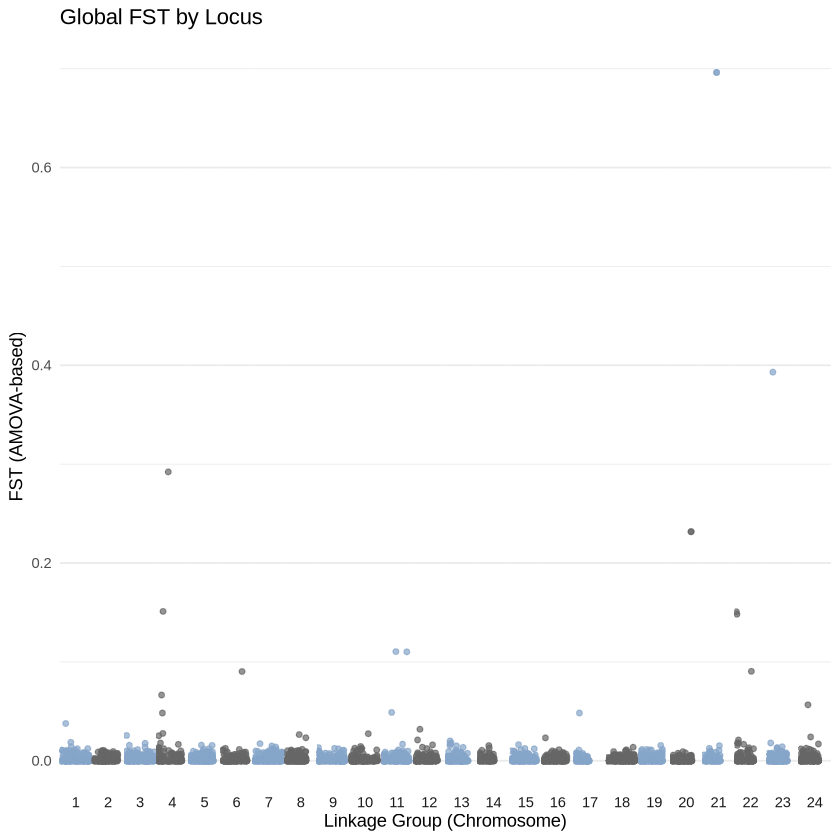

In [42]:
ggplot(globalfst, aes(x = position, y = FST)) +
    geom_point(aes(color = contig), alpha = 0.7, size = 1.3)+
    scale_color_manual(values = rep(c("#85a5c9", "grey40"), length(unique(globalfst$contig)))) +
    facet_grid(cols = vars(contig), switch = "x") +
    theme_minimal() +
    xlab("Linkage Group (Chromosome)") +
    ylab("FST (AMOVA-based)") +
    labs(title = "Global FST by Locus") +
    theme(
        legend.position = "none",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.spacing.x = unit(0, "pt"),
        axis.ticks.x = element_blank(),
        axis.text.x = element_blank(),
        strip.background = element_blank(),
        strip.placement = "inside",
        strip.text.x = element_text(margin = margin(t = 0))
    )

In [43]:
ggsave("manhattan.globalFST.png", height = 8, width = 12, units = "in")

In [44]:
head(fst)

,population1,population2,locus,fst,contig,position,cum_position
,<ord>,<ord>,<chr>,<dbl>,<ord>,<int>,<int>
2314,ATL,GOA,Talbacares_lg_1_17079,0.00000,1,17079,17079
2315,ATL,GOA,Talbacares_lg_1_17081,0.00431,1,17081,17081
2316,ATL,GOA,Talbacares_lg_1_17200,0.00420,1,17200,17200
2317,ATL,GOA,Talbacares_lg_1_17203,0.00000,1,17203,17203
2318,ATL,GOA,Talbacares_lg_1_17207,0.03221,1,17207,17207
2319,ATL,GOA,Talbacares_lg_1_397388,0.00000,1,397388,397388


In [45]:
# Compute chromosome size
offset <- fst |>
group_by(contig) %>%
    summarise(chr_len = max(position)) %>%
    # Calculate cumulative position of each chromosome
      mutate(offset = cumsum(chr_len) - chr_len)

fst$cum_position <- fst$position + offset$offset[match(fst$contig, offset$contig)]
tail(fst)

,population1,population2,locus,fst,contig,position,cum_position
,<ord>,<ord>,<chr>,<dbl>,<ord>,<int>,<int>
79081,SEN,VZ,Talbacares_lg_24_15222448,0,24,15222448,455438417
79082,SEN,VZ,Talbacares_lg_24_15222449,0,24,15222449,455438418
79083,SEN,VZ,Talbacares_lg_24_15222462,0,24,15222462,455438431
79084,SEN,VZ,Talbacares_lg_24_15222601,0,24,15222601,455438570
79085,SEN,VZ,Talbacares_lg_24_15351226,0,24,15351226,455567195
79086,SEN,VZ,Talbacares_lg_24_15371475,0,24,15371475,455587444


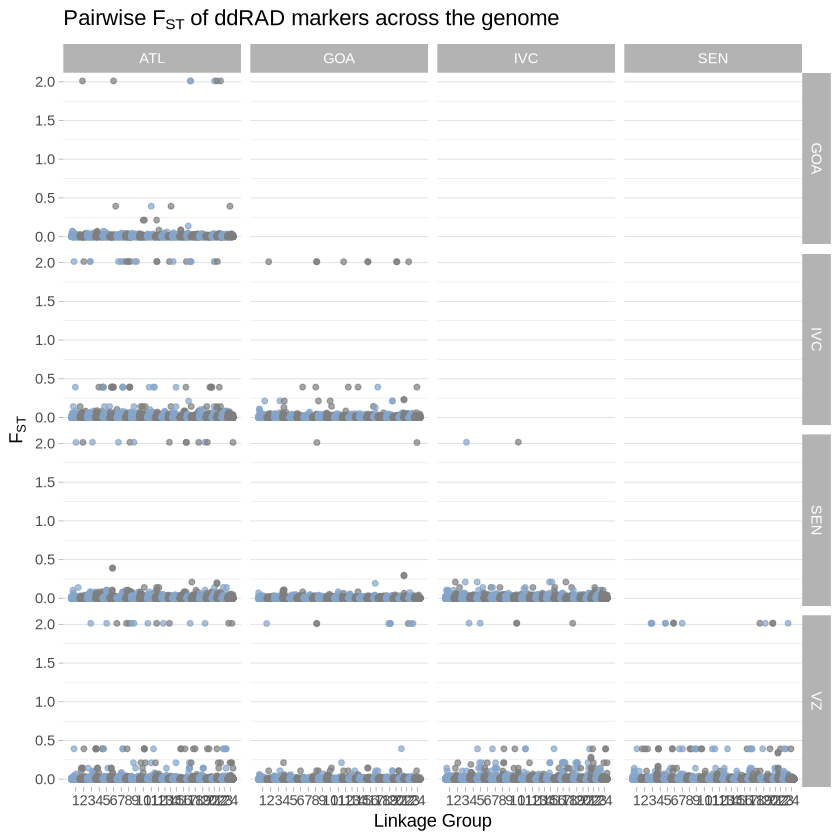

In [46]:
axisdf <- fst %>%
    group_by(contig) %>%
    summarize(center = (max(cum_position) + min(cum_position)) / 2)

ggplot(fst, aes(x = cum_position, y = fst)) +
    # Show all points
    geom_point(aes(color = contig), alpha = 0.7, size = 1.3) +
    scale_color_manual(values = rep(c("#85a5c9", "grey50"), length(unique(fst$contig)))) +

    # custom X axis:
    scale_x_continuous(label = axisdf$contig, breaks = axisdf$center) +
    #scale_y_continuous(expand = c(0, 0)) + # remove space between plot area and x axis
    xlab("Linkage Group") +
    ylab(expression("F"[ST])) +
    labs(title = expression(paste("Pairwise F"[ST], " of ddRAD markers across the genome"))) +
    # Custom the theme:
    facet_grid(vars(population2), vars(population1)) +
    theme_light() +
    theme(
        legend.position = "none",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank()
    )


In [47]:
ggsave("manhattan2.pairwiseFST.png", height = 8, width = 19, units = "in")
